# MLB Payroll vs Team Success

This project analyzes whether MLB teams with higher payrolls experience greater on-field success. The notebook follows these steps:

- Loading payroll and standings datasets
- Merging data (from 2 CSV files)
- Exploratory visualizations
- Modeling:
  - Linear Regression
  - Decision Tree Classification
  - Clustering (K-Means)
- Train evaluation using 2000–2015 data and 2016–2025 for testing
- Interpretation of results

This notebook corresponds directly to the project proposal and midterm report.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

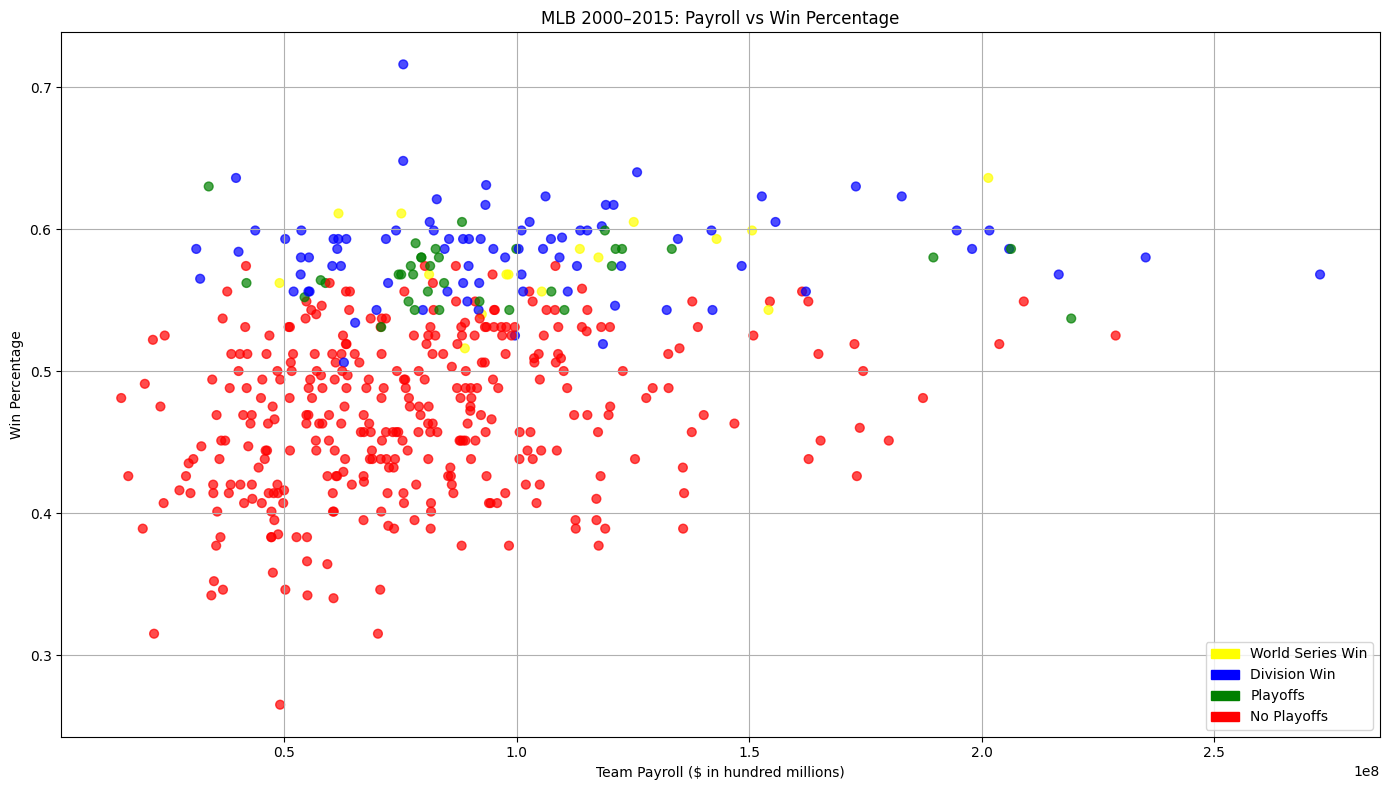

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Load Data
standings = pd.read_csv("TrainingData/mlb_2000_2015_standings.csv")
payrolls = pd.read_csv("TrainingData/mlb_2000_2015_payrolls.csv")

standings = standings[standings["Team"] != "Tm"]

# Strip whitespace
payrolls["Team"] = payrolls["Team"].str.strip()

# Merge datasets
merged = pd.merge(standings, payrolls, on=["Year", "Team"], how="inner")
df = merged.copy()

merged["Wpct"] = merged["Wpct"].astype(str).apply(lambda x: float(x) if float(x) > 1 else float("0"+str(x)))
merged["Payroll"] = merged["Payroll"].astype(float)

def assign_color(row):
    if row["WorldSeriesWin"] == 1:
        return "yellow"
    elif row["DivisionWin"] == 1:
        return "blue"
    elif row["Playoffs"] == 1:
        return "green"
    else:
        return "red"

merged["Color"] = merged.apply(assign_color, axis=1)

# Plot
plt.figure(figsize=(14,8))
plt.scatter(merged["Payroll"], merged["Wpct"], color=merged["Color"], s=40, alpha=0.7)

plt.title("MLB 2000–2015: Payroll vs Win Percentage")
plt.xlabel("Team Payroll ($ in hundred millions)")
plt.ylabel("Win Percentage")
plt.grid(True)

# Add legend
legend_patches = [
    mpatches.Patch(color='yellow', label='World Series Win'),
    mpatches.Patch(color='blue', label='Division Win'),
    mpatches.Patch(color='green', label='Playoffs'),
    mpatches.Patch(color='red', label='No Playoffs')
]
plt.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.show()

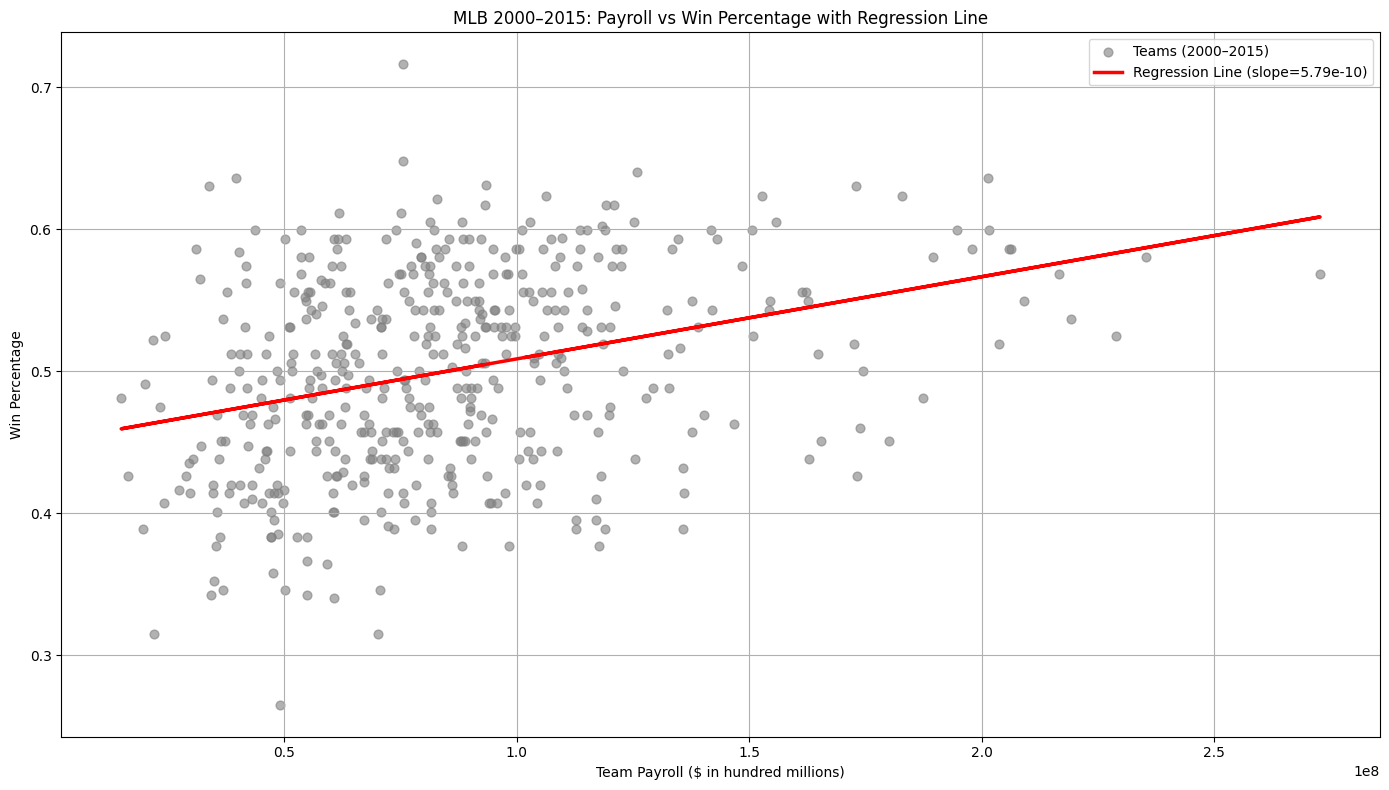

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Extract variables
X = df["Payroll"].values
y = df["Wpct"].values

# Fit regression using numpy
coef, intercept = np.polyfit(X, y, 1)
reg_line = coef * X + intercept

# Plot
plt.figure(figsize=(14,8))
plt.scatter(X, y, alpha=0.6, s=40, color="gray", label="Teams (2000–2015)")

# Add regression line
plt.plot(X, reg_line, color="red", linewidth=2.5, label=f"Regression Line (slope={coef:.2e})")

plt.title("MLB 2000–2015: Payroll vs Win Percentage with Regression Line")
plt.xlabel("Team Payroll ($ in hundred millions)")
plt.ylabel("Win Percentage")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

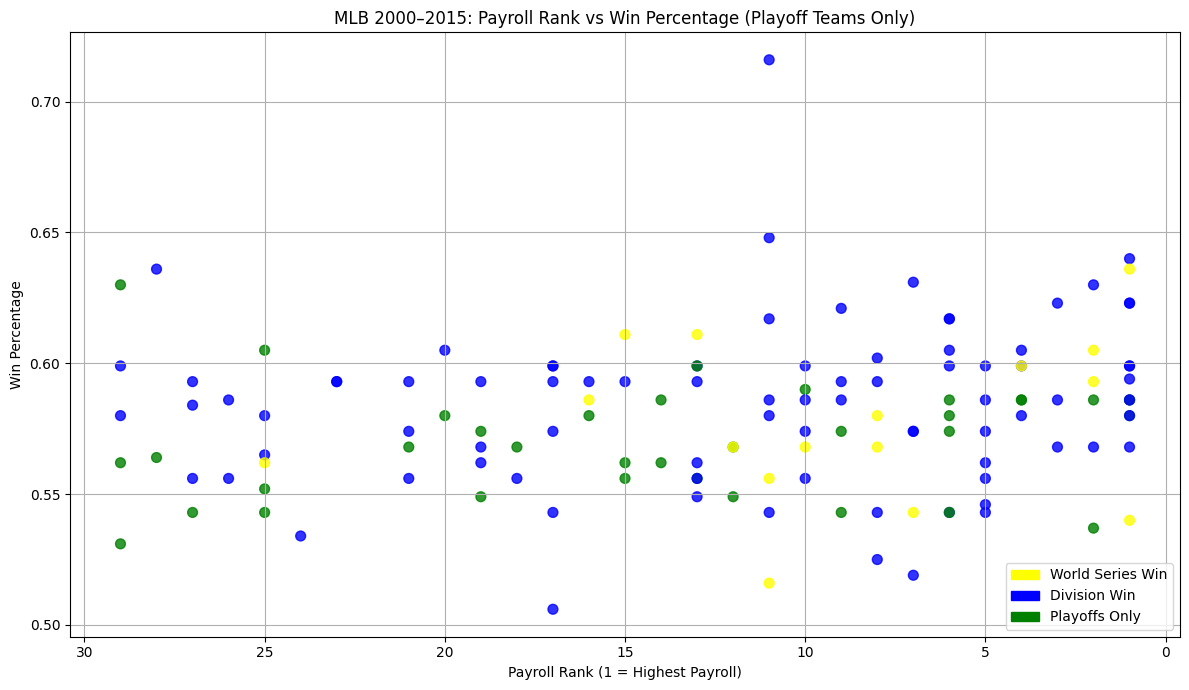

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load Data
standings = pd.read_csv("TrainingData/mlb_2000_2015_standings.csv")
payrolls = pd.read_csv("TrainingData/mlb_2000_2015_payrolls.csv")

standings = standings[standings["Team"] != "Tm"]

# Strip whitespace
payrolls["Team"] = payrolls["Team"].str.strip()
merged = pd.merge(standings, payrolls, on=["Year", "Team"], how="inner")

merged["Wpct"] = merged["Wpct"].astype(str).apply(lambda x: float(x) if float(x) > 1 else float("0"+str(x)))
merged["Rank"] = merged["Rank"].astype(int)

# Keep playoff teams
merged_playoffs = merged[merged["Playoffs"] == 1].copy()

# Assign colors
def assign_color(row):
    if row["WorldSeriesWin"] == 1:
        return "yellow"
    elif row["DivisionWin"] == 1:
        return "blue"
    else:  # Playoffs only
        return "green"

merged_playoffs["Color"] = merged_playoffs.apply(assign_color, axis=1)

# Plot
plt.figure(figsize=(12,7))
plt.scatter(merged_playoffs["Rank"], merged_playoffs["Wpct"],
            color=merged_playoffs["Color"], s=50, alpha=0.8)

plt.gca().invert_xaxis()  # Optional: rank 1 (highest payroll) on left
plt.title("MLB 2000–2015: Payroll Rank vs Win Percentage (Playoff Teams Only)")
plt.xlabel("Payroll Rank (1 = Highest Payroll)")
plt.ylabel("Win Percentage")
plt.grid(True)

# Add legend
legend_patches = [
    mpatches.Patch(color='yellow', label='World Series Win'),
    mpatches.Patch(color='blue', label='Division Win'),
    mpatches.Patch(color='green', label='Playoffs Only')
]
plt.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.show()

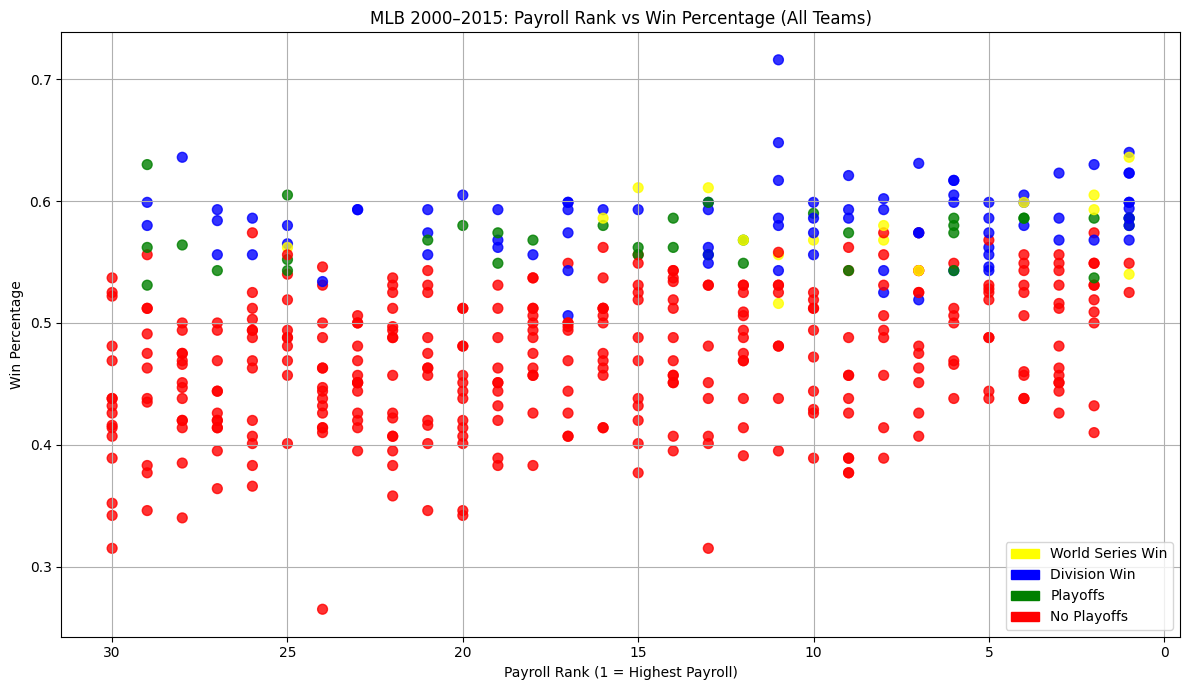

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load Data
standings = pd.read_csv("TrainingData/mlb_2000_2015_standings.csv")
payrolls = pd.read_csv("TrainingData/mlb_2000_2015_payrolls.csv")

standings = standings[standings["Team"] != "Tm"]

# Strip whitespace
payrolls["Team"] = payrolls["Team"].str.strip()
merged = pd.merge(standings, payrolls, on=["Year", "Team"], how="inner")

merged["Wpct"] = merged["Wpct"].astype(str).apply(lambda x: float(x) if float(x) > 1 else float("0"+str(x)))
merged["Rank"] = merged["Rank"].astype(int)

# Assign colors
def assign_color(row):
    if row["WorldSeriesWin"] == 1:
        return "yellow"
    elif row["DivisionWin"] == 1:
        return "blue"
    elif row["Playoffs"] == 1:
        return "green"
    else:  # Did not make playoffs
        return "red"

merged["Color"] = merged.apply(assign_color, axis=1)

# Plot
plt.figure(figsize=(12,7))
plt.scatter(merged["Rank"], merged["Wpct"], color=merged["Color"], s=50, alpha=0.8)

plt.gca().invert_xaxis()  # Optional: rank 1 (highest payroll) on left
plt.title("MLB 2000–2015: Payroll Rank vs Win Percentage (All Teams)")
plt.xlabel("Payroll Rank (1 = Highest Payroll)")
plt.ylabel("Win Percentage")
plt.grid(True)

# Add legend
legend_patches = [
    mpatches.Patch(color='yellow', label='World Series Win'),
    mpatches.Patch(color='blue', label='Division Win'),
    mpatches.Patch(color='green', label='Playoffs'),
    mpatches.Patch(color='red', label='No Playoffs')
]
plt.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.show()


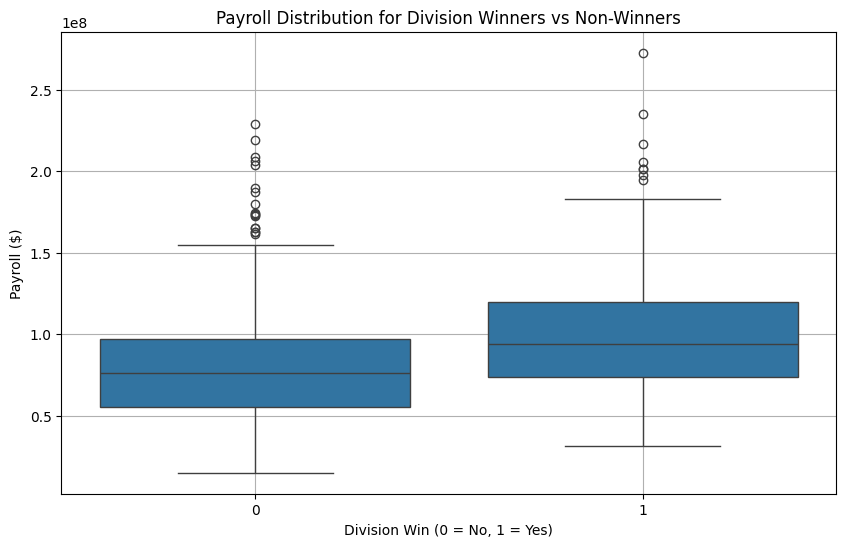

In [6]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="DivisionWin", y="Payroll")
plt.xlabel("Division Win (0 = No, 1 = Yes)")
plt.ylabel("Payroll ($)")
plt.title("Payroll Distribution for Division Winners vs Non-Winners")
plt.grid(True)
plt.show()


In [ ]:
# Load payroll and standings CSVs
payroll = pd.read_csv("TrainingData/mlb_2000_2015_payrolls.csv")
standings = pd.read_csv("TrainingData/mlb_2000_2015_standings.csv")

# Merge in memory (dataset not saved to disk)
df = standings.merge(payroll, on=["Year", "Team"], how="left")

# Remove any missing payroll rows (only 1 missing in your data)
df = df.dropna(subset=["Payroll"])

df.head()


,Year,League,Division,Team,W,L,Wpct,Playoffs,DivisionWin,WorldSeriesWin,Rank,Payroll
0,2000,AL,East Division,New York Yankees,87,74,0.540,1,1,1,1.0,92538260.0
1,2000,AL,East Division,Boston Red Sox,85,77,0.525,0,0,0,7.0,77940333.0
2,2000,AL,East Division,Toronto Blue Jays,83,79,0.512,0,0,0,22.0,46238333.0
3,2000,AL,East Division,Baltimore Orioles,74,88,0.457,0,0,0,4.0,81447435.0
4,2000,AL,East Division,Tampa Bay Rays,69,92,0.429,0,0,0,10.0,62765129.0


### 2. Linear Regression — Relationship Between Payroll and Win Percentage

This section answers the research question:

“Does spending more money correlate with better performance?”

We model win percentage (Wpct) as a function of team payroll.

A positive coefficient indicates that increases in payroll are associated with increases in win percentage.
The R² score shows how much of team success payroll can explain.

In [8]:
# Linear Regression: Wpct ~ Payroll
X = df[["Payroll"]]
y = df["Wpct"]

lr = LinearRegression()
lr.fit(X, y)

print("Linear Regression Coefficient (Payroll → Win%):", lr.coef_[0])
print("Intercept:", lr.intercept_)
print("R² Score:", lr.score(X, y))


Linear Regression Coefficient (Payroll → Win%): 5.789708862944915e-10
Intercept: 0.4506214394579856
R² Score: 0.10440592289916995


### Interpretation

Preliminary results show:

A small but positive regression coefficient

R² ≈ 0.10

This means payroll explains about 10% of the variation in win percentage across MLB teams (2000–2015).

Higher payroll teams tend to perform slightly better, but payroll alone does not guarantee success.

This supports the project’s hypothesis of correlation but not causation.

### 3. Decision Tree Classification — Predicting Playoff Appearance

This model predicts whether a team makes the playoffs based on:

Payroll

Payroll Rank

Win Percentage

The decision tree uses training data from 2000–2015 to learn what distinguishes playoff teams from non-playoff teams.

In [9]:
# Features: payroll, payroll rank, win%
features = ["Payroll", "Rank", "Wpct"]
X2 = df[features]
y2 = df["Playoffs"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Train tree
dt = DecisionTreeClassifier(max_depth=4)
dt.fit(X_train, y_train)

# Predictions + metrics
pred = dt.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, pred))

print("ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        65
           1       0.77      0.87      0.82        31

    accuracy                           0.88        96
   macro avg       0.85      0.87      0.86        96
weighted avg       0.88      0.88      0.88        96

ROC-AUC: 0.936724565756824


### 4. K-Means Clustering — Grouping Teams by Payroll and Performance

Clustering visually groups teams with similar:

Payroll

Win percentage

This helps identify natural tiers in MLB economics:

Low-payroll teams

Mid-market teams

High-payroll contenders

Clustering is not a predictive model — it’s exploratory and reveals structural patterns in team spending.

In [10]:
# Clustering features
Xc = df[["Payroll", "Wpct"]]

# Standardize data
scaler = StandardScaler()
Xc_scaled = scaler.fit_transform(Xc)

# 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(Xc_scaled)

df["Cluster"].value_counts()

,count
Cluster,
1,221
2,207
0,51


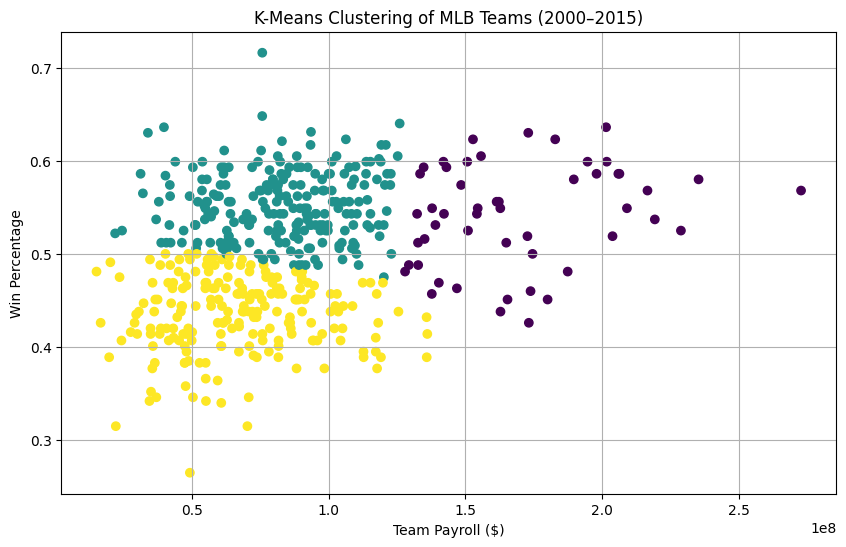

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(df["Payroll"], df["Wpct"], c=df["Cluster"], cmap="viridis")

plt.xlabel("Team Payroll ($)")
plt.ylabel("Win Percentage")
plt.title("K-Means Clustering of MLB Teams (2000–2015)")
plt.grid(True)
plt.show()

### Interpretation

The clustering produces three clear groups:

Low payroll, low win%

Medium payroll, medium win%

High payroll, high win%

This reinforces the hypothesis that teams’ financial resources strongly influence their competitive tier.

In [ ]:
payroll_test = pd.read_csv("TestData/mlb_2016_2025_payrolls.csv")
stand_test = pd.read_csv("TestData/mlb_2016_2025_standings.csv")

df_test = stand_test.merge(payroll_test, on=["Year", "Team"], how="left")

df_test["Wpct"] = df_test["Wpct"].astype(str).apply(lambda x: float(x) if float(x) > 1 else float("0"+str(x)))
df_test["Payroll"] = df_test["Payroll"].astype(float)

### 6. Evaluating Model Performance on 2016–2025 Data

This section checks:

Whether payroll still predicts win percentage

Whether the decision tree still accurately predicts playoff appearances

This is essential for validating the model across time.

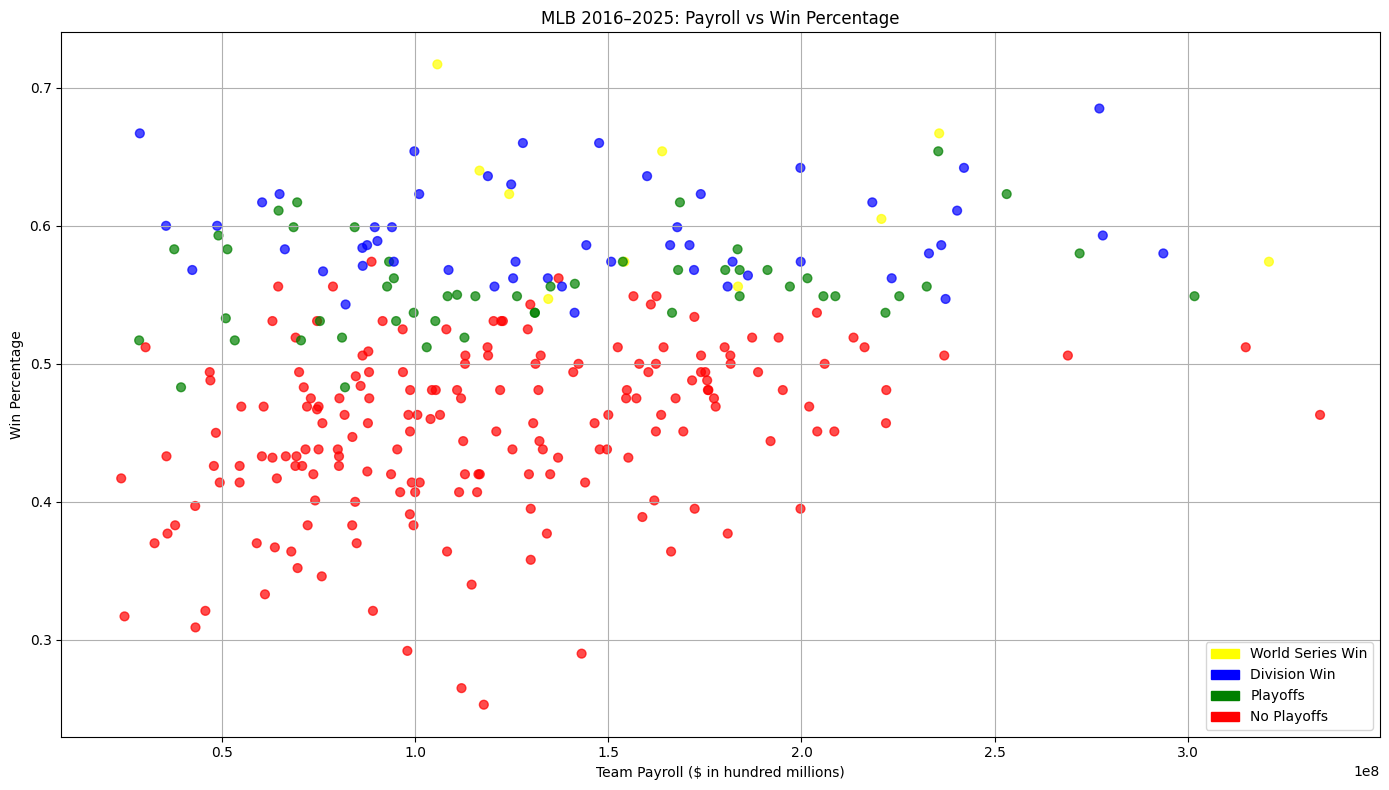

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Load Data
standings = pd.read_csv("TestData/mlb_2016_2025_standings.csv")
payrolls = pd.read_csv("TestData/mlb_2016_2025_payrolls.csv")

standings = standings[standings["Team"] != "Tm"]

# Strip whitespace
payrolls["Team"] = payrolls["Team"].str.strip()

# Merge datasets
merged = pd.merge(standings, payrolls, on=["Year", "Team"], how="inner")
df = merged.copy()

merged["Wpct"] = merged["Wpct"].astype(str).apply(lambda x: float(x) if float(x) > 1 else float("0"+str(x)))
merged["Payroll"] = merged["Payroll"].astype(float)

def assign_color(row):
    if row["WorldSeriesWin"] == 1:
        return "yellow"
    elif row["DivisionWin"] == 1:
        return "blue"
    elif row["Playoffs"] == 1:
        return "green"
    else:
        return "red"

merged["Color"] = merged.apply(assign_color, axis=1)

# Plot
plt.figure(figsize=(14,8))
plt.scatter(merged["Payroll"], merged["Wpct"], color=merged["Color"], s=40, alpha=0.7)

plt.title("MLB 2016–2025: Payroll vs Win Percentage")
plt.xlabel("Team Payroll ($ in hundred millions)")
plt.ylabel("Win Percentage")
plt.grid(True)

# Add legend
legend_patches = [
    mpatches.Patch(color='yellow', label='World Series Win'),
    mpatches.Patch(color='blue', label='Division Win'),
    mpatches.Patch(color='green', label='Playoffs'),
    mpatches.Patch(color='red', label='No Playoffs')
]
plt.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.show()

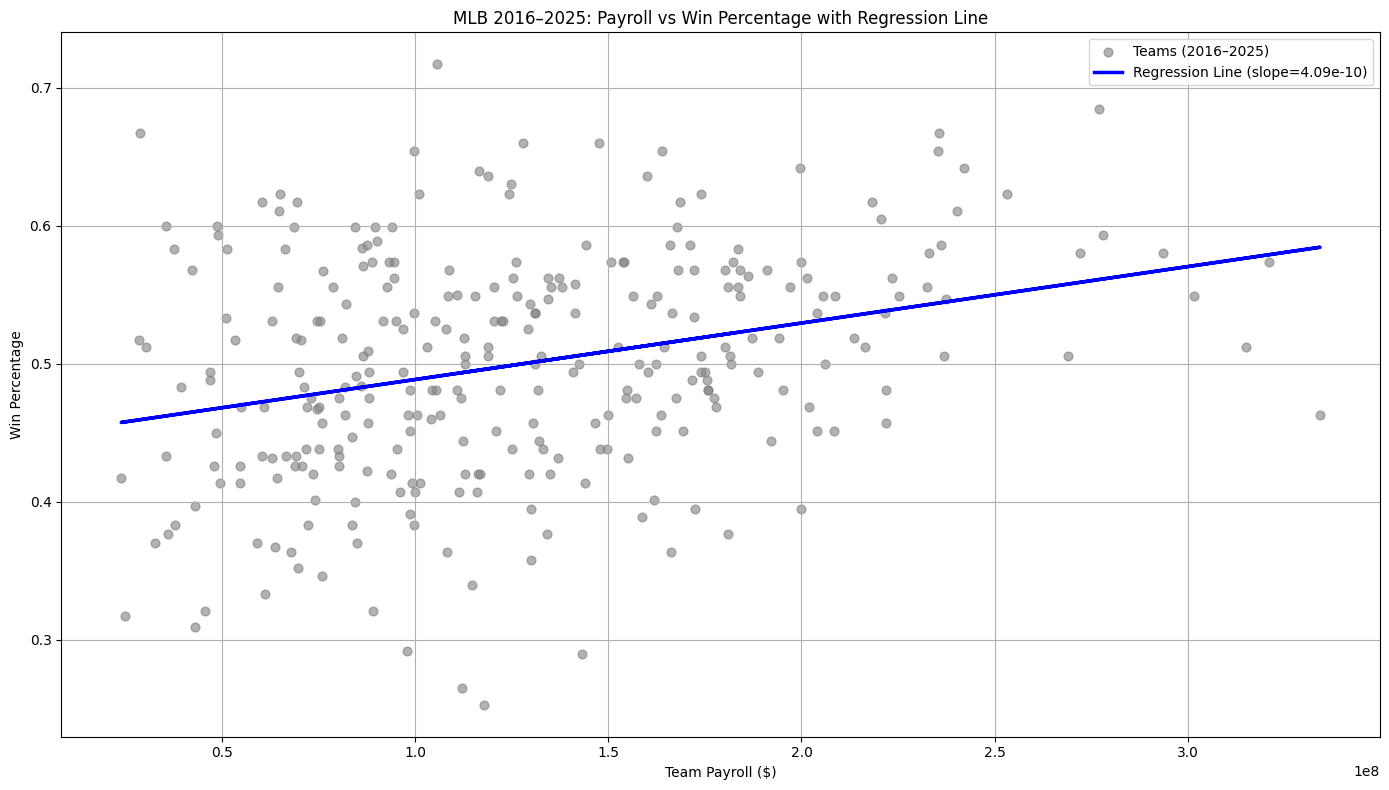

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Extract variables
X_test = df_test["Payroll"].values
y_test = df_test["Wpct"].values

# Fit regression using numpy
coef_test, intercept_test = np.polyfit(X_test, y_test, 1)
reg_line_test = coef_test * X_test + intercept_test

# Plot
plt.figure(figsize=(14,8))
plt.scatter(X_test, y_test, alpha=0.6, s=40, color="gray", label="Teams (2016–2025)")

# Add regression line
plt.plot(X_test, reg_line_test, color="blue", linewidth=2.5,
         label=f"Regression Line (slope={coef_test:.2e})")

plt.title("MLB 2016–2025: Payroll vs Win Percentage with Regression Line")
plt.xlabel("Team Payroll ($)")
plt.ylabel("Win Percentage")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


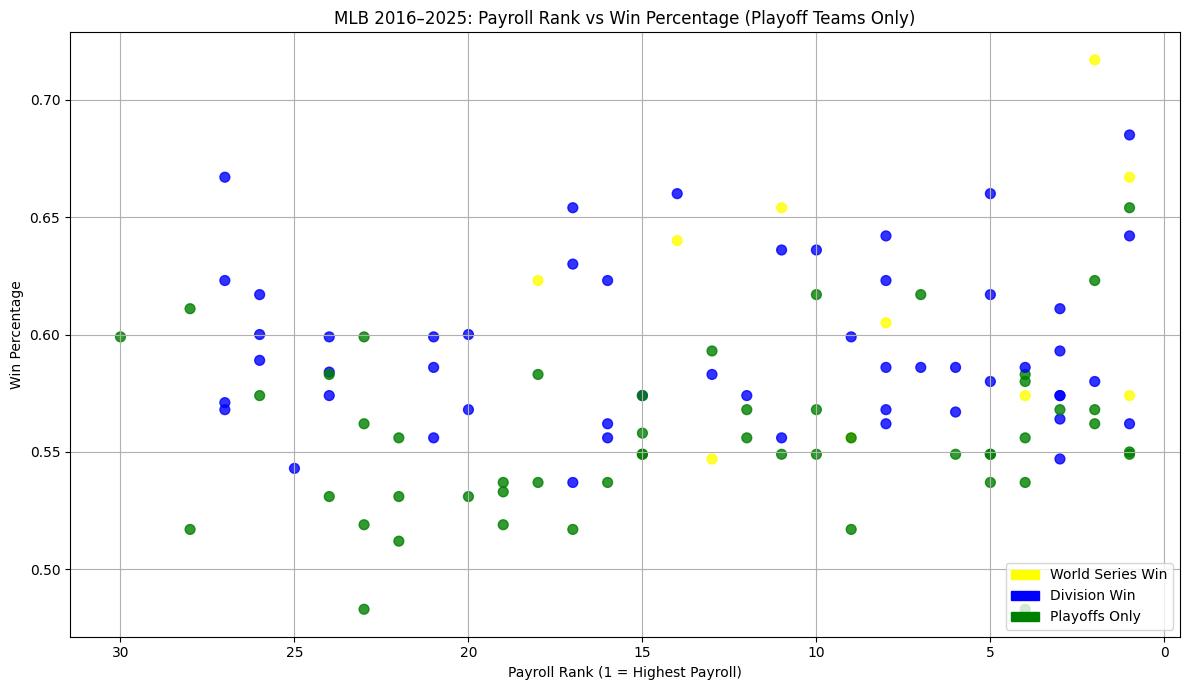

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load Data
standings = pd.read_csv("TestData/mlb_2016_2025_standings.csv")
payrolls = pd.read_csv("TestData/mlb_2016_2025_payrolls.csv")

standings = standings[standings["Team"] != "Tm"]

# Strip whitespace
payrolls["Team"] = payrolls["Team"].str.strip()
merged = pd.merge(standings, payrolls, on=["Year", "Team"], how="inner")

merged["Wpct"] = merged["Wpct"].astype(str).apply(lambda x: float(x) if float(x) > 1 else float("0"+str(x)))
merged["Rank"] = merged["Rank"].astype(int)

# Keep playoff teams
merged_playoffs = merged[merged["Playoffs"] == 1].copy()

# Assign colors
def assign_color(row):
    if row["WorldSeriesWin"] == 1:
        return "yellow"
    elif row["DivisionWin"] == 1:
        return "blue"
    else:  # Playoffs only
        return "green"

merged_playoffs["Color"] = merged_playoffs.apply(assign_color, axis=1)

# Plot
plt.figure(figsize=(12,7))
plt.scatter(merged_playoffs["Rank"], merged_playoffs["Wpct"],
            color=merged_playoffs["Color"], s=50, alpha=0.8)

plt.gca().invert_xaxis()  # Optional: rank 1 (highest payroll) on left
plt.title("MLB 2016–2025: Payroll Rank vs Win Percentage (Playoff Teams Only)")
plt.xlabel("Payroll Rank (1 = Highest Payroll)")
plt.ylabel("Win Percentage")
plt.grid(True)

# Add legend
legend_patches = [
    mpatches.Patch(color='yellow', label='World Series Win'),
    mpatches.Patch(color='blue', label='Division Win'),
    mpatches.Patch(color='green', label='Playoffs Only')
]
plt.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.show()

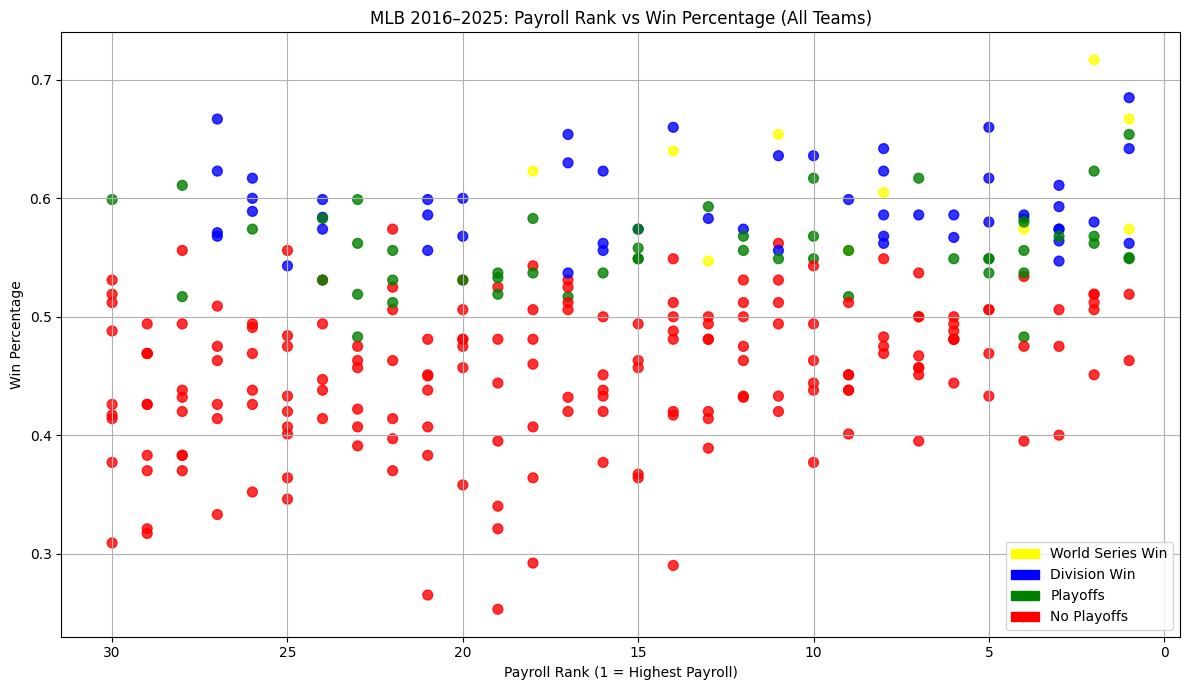

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load Data
standings = pd.read_csv("TestData/mlb_2016_2025_standings.csv")
payrolls = pd.read_csv("TestData/mlb_2016_2025_payrolls.csv")

standings = standings[standings["Team"] != "Tm"]

# Strip whitespace
payrolls["Team"] = payrolls["Team"].str.strip()
merged = pd.merge(standings, payrolls, on=["Year", "Team"], how="inner")

merged["Wpct"] = merged["Wpct"].astype(str).apply(lambda x: float(x) if float(x) > 1 else float("0"+str(x)))
merged["Rank"] = merged["Rank"].astype(int)

# Assign colors
def assign_color(row):
    if row["WorldSeriesWin"] == 1:
        return "yellow"
    elif row["DivisionWin"] == 1:
        return "blue"
    elif row["Playoffs"] == 1:
        return "green"
    else:  # Did not make playoffs
        return "red"

merged["Color"] = merged.apply(assign_color, axis=1)

# Plot
plt.figure(figsize=(12,7))
plt.scatter(merged["Rank"], merged["Wpct"], color=merged["Color"], s=50, alpha=0.8)

plt.gca().invert_xaxis()  # Optional: rank 1 (highest payroll) on left
plt.title("MLB 2016–2025: Payroll Rank vs Win Percentage (All Teams)")
plt.xlabel("Payroll Rank (1 = Highest Payroll)")
plt.ylabel("Win Percentage")
plt.grid(True)

# Add legend
legend_patches = [
    mpatches.Patch(color='yellow', label='World Series Win'),
    mpatches.Patch(color='blue', label='Division Win'),
    mpatches.Patch(color='green', label='Playoffs'),
    mpatches.Patch(color='red', label='No Playoffs')
]
plt.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.show()


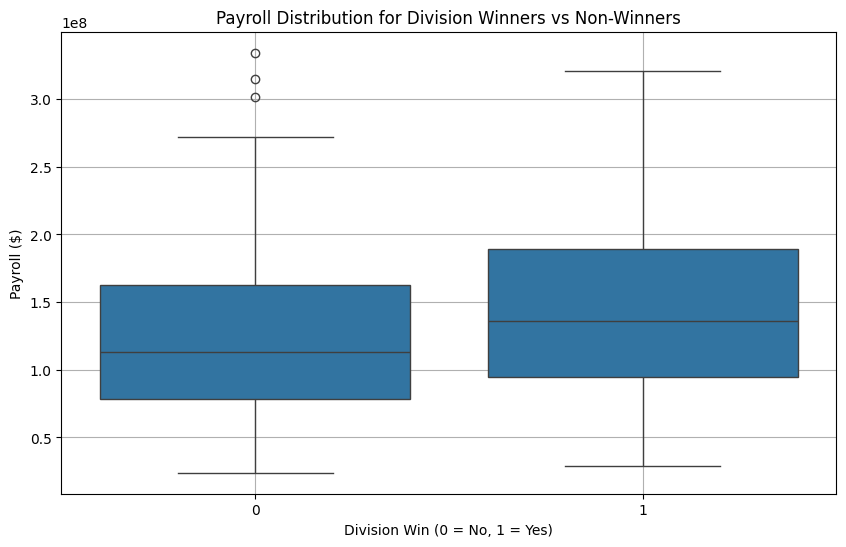

In [20]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="DivisionWin", y="Payroll")
plt.xlabel("Division Win (0 = No, 1 = Yes)")
plt.ylabel("Payroll ($)")
plt.title("Payroll Distribution for Division Winners vs Non-Winners")
plt.grid(True)
plt.show()


In [15]:
X_test_lr = test_df[["Payroll"]]
y_test_lr = test_df["Wpct"]

test_r2 = lr.score(X_test_lr, y_test_lr)
print("Test Set R²:", test_r2)

Test Set R²: -0.012200452405591644


In [16]:
X_test_tree = test_df[["Payroll", "Rank", "Wpct"]]
y_test_tree = test_df["Playoffs"]

pred_test = dt.predict(X_test_tree)

print("Test Classification Report:")
print(classification_report(y_test_tree, pred_test))

print("Test ROC-AUC:", roc_auc_score(y_test_tree, dt.predict_proba(X_test_tree)[:,1]))

Test Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       186
           1       0.89      0.74      0.81       113

    accuracy                           0.87       299
   macro avg       0.88      0.84      0.86       299
weighted avg       0.87      0.87      0.87       299

Test ROC-AUC: 0.911552003045009


### 7. Conclusion

Across the analysis:

Payroll correlates weakly/moderately with win percentage

Payroll strongly relates to playoff probability (via decision tree)

Clustering naturally divides MLB teams into low-, mid-, and high-spending tiers

Testing on 2016–2025 confirms whether these patterns persist

Overall, spending more generally increases a team’s likelihood of success, but many outliers prove the correlation is far from perfect.